# Project 3 - Stiching Photo Mosaics

In [123]:
# load libraries
import numpy as np
import skimage as sk
import skimage.io as skio
from skimage import img_as_ubyte
import matplotlib.pyplot as plt
from skimage.transform import resize

## A.2 Recover Homographies

In [ ]:
def computeH(im1_pts, im2_pts):
    # Ah = b
    # solving using least squares

    n = im1_pts.shape[0]
    A = []
    b = []

    for i in range(n):
        x, y = im1_pts[i]
        xp, yp = im2_pts[i]
        row1 = [x, y, 1, 0, 0, 0, -x * xp, -y * xp]
        row2 = [0, 0, 0, x, y, 1, -x * yp, -y * yp]

        A.append(row1)
        A.append(row2)
        b.append(xp)
        b.append(yp)

    A = np.array(A)
    b = np.array(b)

    # using np least squares solver
    h = np.linalg.lstsq(A, b, rcond=None)[0] # select first element

    H = np.append(h, 1).reshape((3, 3))

    return H


In [86]:
%matplotlib qt

In [ ]:
# load images
im1 = skio.imread("pics/grimes1.png")
im2 = skio.imread("pics/grimes2.png")

# choose pts im1
plt.imshow(im1)
plt.title("Click 4+ points in Image 1, enter to close the window when done")
pts1 = np.array(plt.ginput(n=-1, timeout=0)) # click as many points as needed ?
plt.close()

In [88]:
# choose pts im2
plt.imshow(im2)
plt.title("Click corresponding points in Image 2, same order")
pts2 = np.array(plt.ginput(n=len(pts1), timeout=0))
plt.close()

print("Points from image 1:\n", pts1)
print("Points from image 2:\n", pts2)

Points from image 1:
 [[264.95454545 158.46103896]
 [410.40909091 107.81168831]
 [588.33116883 190.92857143]
 [516.9025974  267.55194805]
 [371.44805195 287.03246753]]
Points from image 2:
 [[ 71.44805195 141.57792208]
 [237.68181818 119.5       ]
 [383.13636364 210.40909091]
 [320.7987013  281.83766234]
 [184.43506494 293.52597403]]


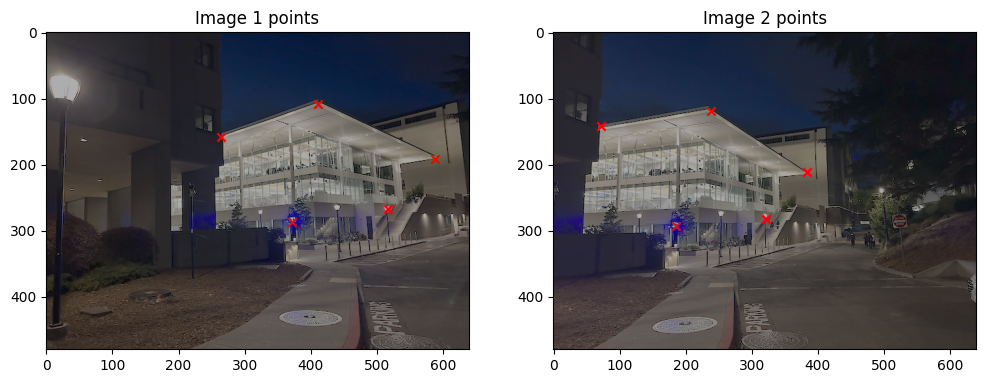

In [89]:
%matplotlib inline

# visual side by side comparison of chosen img pts
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(im1)
axes[0].scatter(pts1[:, 0], pts1[:, 1], c='r', marker='x')
axes[0].set_title("Image 1 points")

axes[1].imshow(im2)
axes[1].scatter(pts2[:, 0], pts2[:, 1], c='r', marker='x')
axes[1].set_title("Image 2 points")

plt.savefig('output/grimes_homography.png')
plt.show()

In [90]:
H = computeH(pts1, pts2)
print("Recovered Homography:\n", H)

Recovered Homography:
 [[ 1.60904060e+00 -2.20491579e-01 -3.01711667e+02]
 [ 3.70956942e-01  1.25978761e+00 -1.22533018e+02]
 [ 1.14276180e-03 -5.01873778e-04  1.00000000e+00]]


In [91]:
%matplotlib qt
# load images
im1 = skio.imread("pics/floor1.png")
im2 = skio.imread("pics/floor2.png")

# choose pts im1
plt.imshow(im1)
plt.title("Click 4+ points in Image 1, close the window when done")
pts1 = np.array(plt.ginput(n=-1, timeout=0)) # click as many points as needed ?
plt.close()

In [92]:
# choose pts im2
plt.imshow(im2)
plt.title("Click corresponding points in Image 2, same order")
pts2 = np.array(plt.ginput(n=len(pts1), timeout=0))
plt.close()

print("Points from image 1:\n", pts1)
print("Points from image 2:\n", pts2)

Points from image 1:
 [[311.70779221 389.62987013]
 [318.2012987  315.6038961 ]
 [477.94155844 309.11038961]
 [342.87662338 197.42207792]
 [383.13636364 207.81168831]]
Points from image 2:
 [[ 94.82467532 450.66883117]
 [101.31818182 355.86363636]
 [285.73376623 314.30519481]
 [142.87662338 210.40909091]
 [187.03246753 218.2012987 ]]


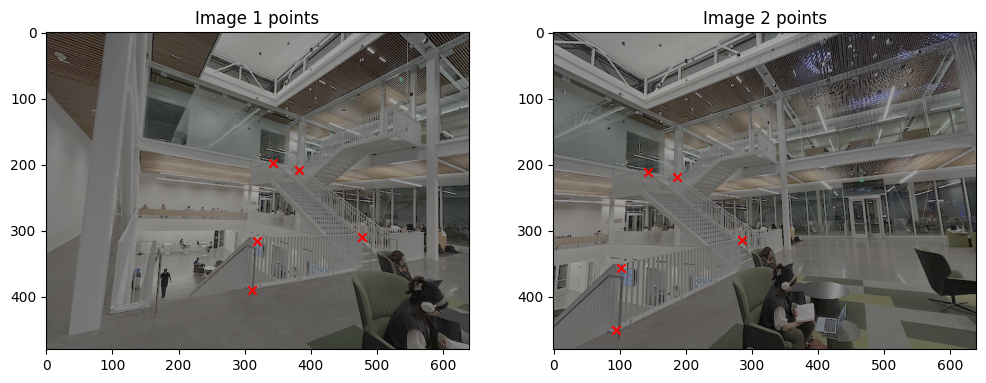

In [93]:
%matplotlib inline

# visual side by side comparison of chosen img pts
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(im1)
axes[0].scatter(pts1[:, 0], pts1[:, 1], c='r', marker='x')
axes[0].set_title("Image 1 points")

axes[1].imshow(im2)
axes[1].scatter(pts2[:, 0], pts2[:, 1], c='r', marker='x')
axes[1].set_title("Image 2 points")

plt.savefig('output/floor_homography.png')
plt.show()


In [94]:
H = computeH(pts1, pts2)
print("Recovered Homography:\n", H)

Recovered Homography:
 [[ 1.34953238e+00 -1.02735203e-01 -2.84574897e+02]
 [-6.49643399e-02  1.20693002e+00  1.95695271e+01]
 [ 5.01632297e-04 -2.92740559e-04  1.00000000e+00]]


## A.3 Warp the Images

In [95]:
# handling if warped images might extend outide original frame
def compute_output_bounds(im, H):
    h, w = im.shape[:2]
    corners = np.array([[0, 0, 1],
                        [w-1, 0, 1],
                        [0, h-1, 1],
                        [w-1, h-1, 1]])
    warped = (H @ corners.T).T # transform corners of input with H
    warped = warped[:, :2] / warped[:, 2:] # normalize
    min_x, min_y = warped.min(axis=0)
    max_x, max_y = warped.max(axis=0)
    return int(np.floor(min_x)), int(np.floor(min_y)), int(np.ceil(max_x)), int(np.ceil(max_y))

In [96]:
def warpImageNearestNeighbor(im, H):
    Hinv = np.linalg.inv(H)
    h, w = im.shape[:2]
    
    # find output bounds
    min_x, min_y, max_x, max_y = compute_output_bounds(im, H)
    out_w, out_h = max_x - min_x, max_y - min_y
    
    out = np.zeros((out_h, out_w, im.shape[2]), dtype=im.dtype)
    
    for yy in range(out_h):
        for xx in range(out_w):
            # coords in output image
            x_out, y_out = xx + min_x, yy + min_y
            
            # map back into input coords
            src = Hinv @ np.array([x_out, y_out, 1])
            x_src, y_src = src[0]/src[2], src[1]/src[2]
            
            # nearest neighbor
            xi, yi = int(round(x_src)), int(round(y_src))
            
            if 0 <= xi < w and 0 <= yi < h:
                out[yy, xx] = im[yi, xi]
    
    return out

In [97]:
def warpImageBilinear(im, H):
    Hinv = np.linalg.inv(H)
    h, w = im.shape[:2]
    
    min_x, min_y, max_x, max_y = compute_output_bounds(im, H)
    out_w, out_h = max_x - min_x, max_y - min_y
    
    out = np.zeros((out_h, out_w, im.shape[2]), dtype=im.dtype)
    
    for yy in range(out_h):
        for xx in range(out_w):
            x_out, y_out = xx + min_x, yy + min_y
            src = Hinv @ np.array([x_out, y_out, 1])
            x_src, y_src = src[0]/src[2], src[1]/src[2]
            
            if 0 <= x_src < w-1 and 0 <= y_src < h-1:
                # floor and ceil
                x0, y0 = int(np.floor(x_src)), int(np.floor(y_src))
                dx, dy = x_src - x0, y_src - y0
                
                # grab 4 neighbors
                top_left = im[y0, x0]
                top_right = im[y0, x0+1]
                bottom_left = im[y0+1, x0]
                bottom_right = im[y0+1, x0+1]
                
                # bilinear interpolate
                top = (1-dx)*top_left + dx*top_right
                bottom = (1-dx)*bottom_left + dx*bottom_right
                value = (1-dy)*top + dy*bottom
                
                out[yy, xx] = value
    
    return out.astype(im.dtype)

In [98]:
%matplotlib qt

# load rectangle image
im = skio.imread("pics/poke.png")

plt.imshow(im)
plt.title("Click 4 corners of the rectangle (clockwise)") # why clockwise?
pts = plt.ginput(4, timeout=0)
plt.close()

im1_pts = np.array(pts) # (4x2)
print("Points from image:", im1_pts)

# need to define correspondences based on what we know about image
# define by hand
width, height = 500, 400 # how much does this impact warping?
im2_pts = np.array([
    [0, 0],
    [width-1, 0],
    [width-1, height-1],
    [0, height-1]
])

# compute homography
H = computeH(im1_pts, im2_pts)
print("Recovered Homography:\n", H)

Points from image: [[325.47402597 151.88095238]
 [589.54329004 316.38311688]
 [314.65151515 729.8030303 ]
 [ 18.11471861 509.02380952]]
Recovered Homography:
 [[ 1.35763786e+00  1.16839137e+00 -6.19332255e+02]
 [-5.62759617e-01  9.03377280e-01  4.59578366e+01]
 [-8.10202797e-05  4.78530311e-04  1.00000000e+00]]


In [99]:
# warp image (nearest neighbor)
im_warp_nn = warpImageNearestNeighbor(im, H)

In [100]:
# warp image (bilinear)
im_warp_bil = warpImageBilinear(im, H)

In [101]:

# visualize
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
axs[0].imshow(im)
axs[0].set_title("Original Image")
axs[1].imshow(im_warp_nn)
axs[1].set_title("Warped - Nearest Neighbor")
axs[2].imshow(im_warp_bil)
axs[2].set_title("Warped - Bilinear")

plt.savefig('output/poke_warped.png')
plt.show()

In [102]:
# load rectangle image
im = skio.imread("pics/bagel.png")

plt.imshow(im)
plt.title("Click 4 corners of the rectangle (clockwise)") # why clockwise?
pts = plt.ginput(4, timeout=0)
plt.close()

im1_pts = np.array(pts) # (4x2)
print("Points from image:", im1_pts)

# need to define correspondences based on what we know about image
# define by hand
width, height = 500, 350 # how much does this impact warping?
im2_pts = np.array([
    [0, 0],
    [width-1, 0],
    [width-1, height-1],
    [0, height-1]
])

# compute homography
H = computeH(im1_pts, im2_pts)
print("Recovered Homography:\n", H)

Points from image: [[ 76.55627706 381.31818182]
 [286.51298701 292.57359307]
 [494.30519481 606.42640693]
 [212.91991342 766.5995671 ]]
Recovered Homography:
 [[ 3.37835970e+00 -1.19571158e+00  1.97311924e+02]
 [ 8.40570280e-01  1.98866627e+00 -8.22665539e+02]
 [ 2.55970036e-04  1.91669358e-03  1.00000000e+00]]


In [103]:
# warp image (nearest neighbor)
im_warp_nn = warpImageNearestNeighbor(im, H)

In [104]:
# warp image (bilinear)
im_warp_bil = warpImageBilinear(im, H)

In [105]:
# visualize
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
axs[0].imshow(im)
axs[0].set_title("Original Image")
axs[1].imshow(im_warp_nn)
axs[1].set_title("Warped - Nearest Neighbor")
axs[2].imshow(im_warp_bil)
axs[2].set_title("Warped - Bilinear")

plt.savefig('output/bagel_warped.png')
plt.show()

## A.4 Blend the Images into a Mosaic

In [ ]:
# def create_mosaic(im1, im2, pts1, pts2):
#     """
#     Warp im2 into im1's coordinate system and blend into a mosaic.
    
#     Args:
#         im1, im2: images (H x W x 3)
#         pts1, pts2: corresponding points in im1 and im2
    
#     Returns:
#         mosaic: blended image as uint8
#     """
#     # Compute homography from im2 -> im1
#     H = computeH(pts2, pts1)

#     # Compute bounds of im2 when warped
#     min_x2, min_y2, max_x2, max_y2 = compute_output_bounds(im2, H)

#     # Compute global mosaic bounds
#     min_x = min(0, min_x2)
#     min_y = min(0, min_y2)
#     max_x = max(im1.shape[1], max_x2)
#     max_y = max(im1.shape[0], max_y2)

#     out_w, out_h = max_x - min_x, max_y - min_y
#     x_off, y_off = -min_x, -min_y

#     # Initialize mosaic and weight
#     mosaic = np.zeros((out_h, out_w, 3), dtype=np.float32)
#     weight = np.zeros((out_h, out_w), dtype=np.float32)

#     # Paste im1 onto mosaic
#     mosaic[y_off:y_off+im1.shape[0], x_off:x_off+im1.shape[1]] = im1
#     weight[y_off:y_off+im1.shape[0], x_off:x_off+im1.shape[1]] = 1

#     # Shift homography to global canvas
#     H_shift = np.array([[1, 0, x_off],
#                         [0, 1, y_off],
#                         [0, 0, 1]]) @ H

#     # Warp im2 (size matches im2 bounds)
#     im2_warp = warpImageBilinear(im2, H_shift)

#     # Paste im2_warp into global canvas
#     temp_canvas = np.zeros_like(mosaic)
#     mask2 = np.zeros((out_h, out_w), dtype=np.float32)

#     # Determine where to paste in global mosaic
#     x_start = max(0, x_off + min_x2)
#     y_start = max(0, y_off + min_y2)
#     h_warp, w_warp = im2_warp.shape[:2]

#     temp_canvas[y_start:y_start+h_warp, x_start:x_start+w_warp] = im2_warp
#     mask2[y_start:y_start+h_warp, x_start:x_start+w_warp] = (im2_warp.sum(axis=2) > 0)

#     # Blend images using simple feathering
#     mosaic = (mosaic + temp_canvas) / (weight[..., None] + mask2[..., None] + 1e-8)

#     return np.clip(mosaic, 0, 255).astype(np.uint8)

In [106]:
def warpMosaicBilinear(im, H, output_shape):
    H_inv = np.linalg.inv(H)
    out_h, out_w = output_shape
    src_h, src_w = im.shape[:2]

    y_out, x_out = np.indices((out_h, out_w))
    # not looping over each pixel, creating all coordinates at the same tme
    out_coords = np.stack((x_out.ravel(), y_out.ravel(), np.ones(out_h * out_w)))

    src_coords = H_inv @ out_coords # apply inverse warping to all coordinates
    src_coords /= src_coords[2, :]

    x_src = src_coords[0, :].reshape(out_h, out_w)
    y_src = src_coords[1, :].reshape(out_h, out_w)
    
    x0 = np.floor(x_src).astype(int)
    y0 = np.floor(y_src).astype(int)
    x1 = x0 + 1
    y1 = y0 + 1

    dx = x_src - x0
    dy = y_src - y0
    
    valid_mask = (x0 >= 0) & (x1 < src_w) & (y0 >= 0) & (y1 < src_h)

    warped_im = np.zeros((out_h, out_w, im.shape[2]), dtype=im.dtype)

    for channel in range(im.shape[2]):
        y0_v, x0_v = y0[valid_mask], x0[valid_mask]
        y1_v, x1_v = y1[valid_mask], x1[valid_mask]
        dy_v, dx_v = dy[valid_mask], dx[valid_mask]

        p00 = im[y0_v, x0_v, channel]
        p01 = im[y0_v, x1_v, channel]
        p10 = im[y1_v, x0_v, channel]
        p11 = im[y1_v, x1_v, channel]

        # speed up weighted average calculations
        top = (1 - dx_v) * p00 + dx_v * p01
        bottom = (1 - dx_v) * p10 + dx_v * p11
        
        interpolated_val = (1 - dy_v) * top + dy_v * bottom

        channel_out = np.zeros((out_h, out_w))
        channel_out[valid_mask] = interpolated_val
        warped_im[:, :, channel] = channel_out

    return warped_im

In [107]:
from scipy.ndimage import distance_transform_edt

def create_mosaic(im1, im2, pts1, pts2):
    H_2_to_1 = computeH(pts2, pts1)
    
    h1, w1 = im1.shape[:2]
    corners1 = np.array([[0, 0], [w1, 0], [w1, h1], [0, h1]])
    
    h2, w2 = im2.shape[:2]
    corners2 = np.array([[0, 0, 1], [w2, 0, 1], [w2, h2, 1], [0, h2, 1]]).T
    corners2_transformed = H_2_to_1 @ corners2
    corners2_transformed = (corners2_transformed / corners2_transformed[2, :])[:2, :].T # find corners post transformation

    all_corners = np.vstack((corners1, corners2_transformed)) # all corners in final combined mosaic
    
    min_x, min_y = np.min(all_corners, axis=0)
    max_x, max_y = np.max(all_corners, axis=0)
    
    out_w = int(np.ceil(max_x - min_x))
    out_h = int(np.ceil(max_y - min_y))
    x_offset = -min_x
    y_offset = -min_y

    T = np.array([[1, 0, x_offset], 
                  [0, 1, y_offset], 
                  [0, 0, 1]])
    # T matrix to shift coordinates to 0, 0
    
    output_shape = (out_h, out_w) # output dimensions
    
    im1_warped = warpMosaicBilinear(im1, T, output_shape) # place im1 in right position in output, doesn't transform im
    
    H_2_to_canvas = T @ H_2_to_1 # warping and translation T
    im2_warped = warpMosaicBilinear(im2, H_2_to_canvas, output_shape) # warp to combine with im1


    mask1 = (np.sum(im1_warped, axis=2) > 0)
    mask2 = (np.sum(im2_warped, axis=2) > 0)

    weight1 = distance_transform_edt(mask1).astype(np.float32)
    weight2 = distance_transform_edt(mask2).astype(np.float32)

    total_weight = weight1 + weight2
    total_weight[total_weight == 0] = 1e-8 # Avoid division by zero

    mosaic = (im1_warped * weight1[..., None] + im2_warped * weight2[..., None]) / total_weight[..., None] # weighted average to smooth out edge artifacts

    return mosaic.astype(np.uint8)

In [108]:
# load images
im1 = skio.imread("pics/grimes1.png")
im2 = skio.imread("pics/grimes2.png")

# choose pts im1, try more than 4 pts for more info
plt.imshow(im1)
plt.title("Click 4+ points in Image 1, close the window when done")
pts1 = np.array(plt.ginput(n=-1, timeout=0)) # click as many points as needed ?
plt.close()

In [109]:
# choose pts im2
plt.imshow(im2)
plt.title("Click corresponding points in Image 2, same order")
pts2 = np.array(plt.ginput(n=len(pts1), timeout=0))
plt.close()

print("Points from image 1:\n", pts1)
print("Points from image 2:\n", pts2)

Points from image 1:
 [[266.25324675 157.16233766]
 [415.6038961  107.81168831]
 [587.03246753 187.03246753]
 [515.6038961  268.85064935]
 [371.44805195 283.13636364]
 [371.44805195 283.13636364]]
Points from image 2:
 [[ 70.14935065 146.77272727]
 [236.38311688 119.5       ]
 [383.13636364 215.6038961 ]
 [320.7987013  281.83766234]
 [185.73376623 292.22727273]]


In [110]:
mosaic = create_mosaic(im1, im2, pts1, pts2)

plt.figure(figsize=(12, 8))
plt.imshow(mosaic)
# plt.axis('off')
plt.title("Stitched Mosaic")
plt.savefig('output/grimes_mosaic')
plt.show()

In [51]:
# load images
im1 = skio.imread("pics/floor1.png")
im2 = skio.imread("pics/floor2.png")

# choose pts im1, try more than 4 pts for more info
plt.imshow(im1)
plt.title("Click 4+ points in Image 1, close the window when done")
pts1 = np.array(plt.ginput(n=-1, timeout=0)) # click as many points as needed ?
plt.close()

# choose pts im2
plt.imshow(im2)
plt.title("Click corresponding points in Image 2, same order")
pts2 = np.array(plt.ginput(n=len(pts1), timeout=0))
plt.close()

print("Points from image 1:\n", pts1)
print("Points from image 2:\n", pts2)

KeyboardInterrupt: 

In [34]:
mosaic = create_mosaic(im1, im2, pts1, pts2)

plt.figure(figsize=(12, 8))
plt.imshow(mosaic)
# plt.axis('off')
plt.title("Stitched Mosaic")
plt.savefig('output/floor_mosaic')
plt.show()

In [ ]:
# load images
im1 = skio.imread("pics/skywalk1.png")
im2 = skio.imread("pics/skywalk2.png")

# NOTE TO SELF: clicked 4 pts = center overlap of mountains, highest pt of mountain in im1, 3rd bar left + right on walkway
# choose pts im1, try more than 4 pts for more info
plt.imshow(im1)
plt.title("Click 4+ points in Image 1, close the window when done")
pts1 = np.array(plt.ginput(n=-1, timeout=0)) # click as many points as needed ?
plt.close()

# choose pts im2
plt.imshow(im2)
plt.title("Click corresponding points in Image 2, same order")
pts2 = np.array(plt.ginput(n=len(pts1), timeout=0))
plt.close()

print("Points from image 1:\n", pts1)
print("Points from image 2:\n", pts2)

Points from image 1:
 [[357.94155844 422.44372294]
 [587.37878788 338.02813853]
 [321.14502165 552.31385281]
 [593.87229437 625.90692641]]
Points from image 2:
 [[109.02380952 454.91125541]
 [331.96753247 381.31818182]
 [ 93.87229437 573.95887446]
 [295.17099567 556.64285714]]


In [63]:
mosaic = create_mosaic(im1, im2, pts1, pts2)

plt.figure(figsize=(12, 8))
plt.imshow(mosaic)
# plt.axis('off')
plt.title("Stitched Mosaic")
plt.savefig('output/skywalk_mosaic.png')
plt.show()

## B.1 Harris Corner Detection

In [112]:
# sample code from spec

import numpy as np
from skimage.feature import corner_harris, peak_local_max


def get_harris_corners(im, edge_discard=20):
    """
    This function takes a b&w image and an optional amount to discard
    on the edge (default is 5 pixels), and finds all harris corners
    in the image. Harris corners near the edge are discarded and the
    coordinates of the remaining corners are returned. A 2d array (h)
    containing the h value of every pixel is also returned.

    h is the same shape as the original image, im.
    coords is 2 x n (ys, xs).
    """

    assert edge_discard >= 20

    # find harris corners
    h = corner_harris(im, method='eps', sigma=1)
    coords = peak_local_max(h, min_distance=1)

    # discard points on edge
    edge = edge_discard  # pixels
    mask = (coords[:, 0] > edge) & \
           (coords[:, 0] < im.shape[0] - edge) & \
           (coords[:, 1] > edge) & \
           (coords[:, 1] < im.shape[1] - edge)
    coords = coords[mask].T
    return h, coords


def dist2(x, c):
    """
    dist2  Calculates squared distance between two sets of points.

    Description
    D = DIST2(X, C) takes two matrices of vectors and calculates the
    squared Euclidean distance between them.  Both matrices must be of
    the same column dimension.  If X has M rows and N columns, and C has
    L rows and N columns, then the result has M rows and L columns.  The
    I, Jth entry is the  squared distance from the Ith row of X to the
    Jth row of C.

    Adapted from code by Christopher M Bishop and Ian T Nabney.
    """

    ndata, dimx = x.shape
    ncenters, dimc = c.shape
    assert dimx == dimc, 'Data dimension does not match dimension of centers'

    return (np.ones((ncenters, 1)) * np.sum((x**2).T, axis=0)).T + \
            np.ones((   ndata, 1)) * np.sum((c**2).T, axis=0)    - \
            2 * np.inner(x, c)

In [127]:
%matplotlib inline

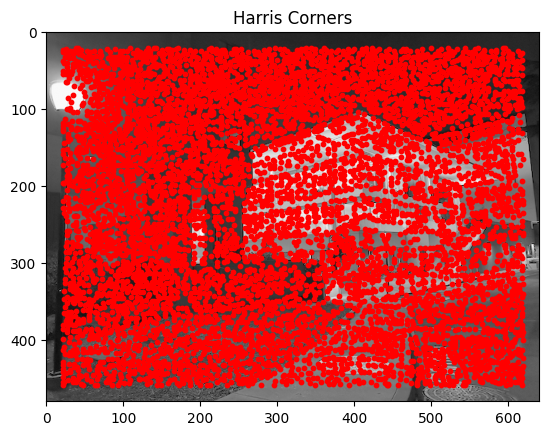

In [128]:
# show Harris corners overlaid on image
im = skio.imread("pics/grimes1.png", as_gray = True)

h, coords = get_harris_corners(im)

plt.imshow(im, cmap = "gray")
plt.scatter(coords[1], coords[0], s = 10, c = 'r', marker = 'o') # coords is 2 x n (ys, xs)
plt.title("Harris Corners")
plt.savefig('output/grimes1_harris_corners.png')
plt.show()

In [130]:
# Adaptive Non-Maximal Suppression

def anms(coords, h, N = 500, c_robust = 0.9):
    """
    inputs:
        coords: 2xN array of [ys, xs]
        h: Harris response map
        N: number of points to keep (paper chose 500 interest pts to keep)
        c_robust: suppression constant

    output:
        selected_coords: 2xN array of ANMS-suppressed coordinates
    """

    # transpose for easier indexing
    ys, xs = coords
    h_vals = h[ys, xs] # Harris corner strength for each corner coordinate

    n_pts = len(h_vals)
    r = np.full(n_pts, np.inf) # initialize the suppression radius for each corner to infinity

    # sort points descending by corner strength
    order = np.argsort(-h_vals) # sort highest to lowest
    xs, ys, h_vals = xs[order], ys[order], h_vals[order]

    for i in range(1, n_pts):
        # indexing with [:i] to look at previous coordinates up until i
        # currently default val for c_robust set to = 0.9, pts give or take 10% less strong considered potentially stronger ?
        stronger = np.where(h_vals[:i] > c_robust * h_vals[i])[0] # all points that are stronger than i using the suppression radius from paper
        if len(stronger) > 0:
            dx = xs[i] - xs[stronger] # distance to nearest stronger corner
            dy = ys[i] - ys[stronger]
            r[i] = np.min(np.sqrt(dx ** 2 + dy ** 2)) # suppression radius

    # pick top N points with largest suppression radius
    top_idx = np.argsort(-r)[:N]
    selected_coords = np.vstack((ys[top_idx], xs[top_idx]))
    return selected_coords

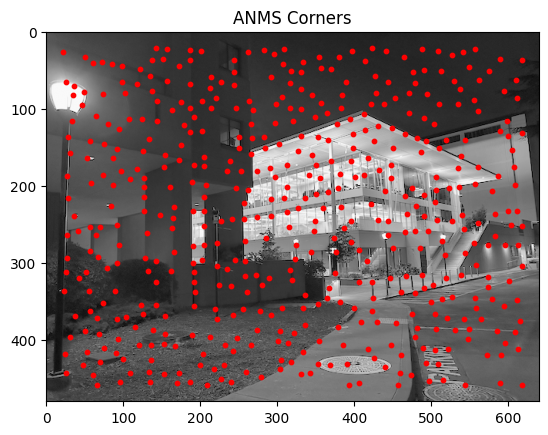

In [151]:
# show image with ANMS chosen corners

anms_coords = anms(coords, h, N = 500) # paper selected the 500 interest pts with the largest r values
plt.imshow(im, cmap = "gray")
plt.scatter(anms_coords[1], anms_coords[0], s = 10, c = 'r', marker = 'o') # coords is 2 x n (ys, xs)
plt.title("ANMS Corners")
plt.savefig('output/grimes1_anms_corners.png')
plt.show()

## B.2 Feature Descriptor Extraction

In [146]:
def feature_descriptor(im, coords):
    """
    Extracts 8x8 feature descriptors centered at given coordinates.

    inputs:
        im: grayscale input image (H x W)
        coords: 2xN array of [ys, xs] coordinates from ANMS

    output:
        fd: (N x 64) array of feature descriptors
        valid_coords: 2xM array of coords that produced valid patches
    """
    half = 40 // 2 # 40x40 window
    H, W = im.shape
    fd = [] # initialize feature descriptors
    valid_coords = []

    for y, x in zip(coords[0], coords[1]):
        # skip points too close to border
        if y - half < 0 or y + half >= H or x - half < 0 or x + half >= W:
            continue

        # extract 40x40 patch
        patch = im[y - half:y + half, x - half:x + half]

        # resize down to 8x8
        small_patch = resize(patch, (8, 8), anti_aliasing = True) # 8x8 patch for extraction

        # bias/gain normalize
        small_patch = small_patch - np.mean(small_patch)
        std = np.std(small_patch)
        if std != 0:
            small_patch = small_patch / std

        # flatten to descriptor vector (length 64)
        fd.append(small_patch.flatten())
        valid_coords.append((y, x))

    fd = np.array(fd)
    valid_coords = np.array(valid_coords).T
    return fd, valid_coords

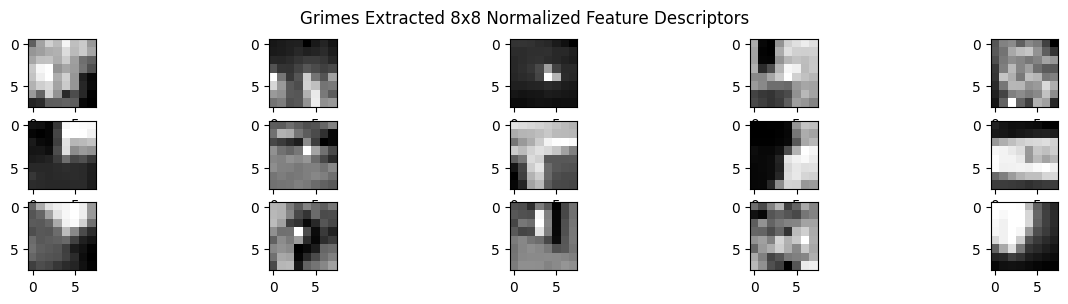

In [152]:
fd, valid_coords = feature_descriptor(im, anms_coords)

plt.figure(figsize=(15, 3)) # showing 10 extracted features
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(fd[i].reshape(8, 8), cmap = 'gray')
    # plt.axis('off')
plt.suptitle("Grimes Extracted 8x8 Normalized Feature Descriptors")
plt.savefig('output/grimes_feature_descriptors.png')
plt.show()

In [154]:
# sanity check
print(f"Harris corners found: {coords.shape[1]}")
print(f"ANMS-selected points: {anms_coords.shape[1]}")
print(f"Feature descriptors extracted: {fd.shape[0]}")

Harris corners found: 6881
ANMS-selected points: 500
Feature descriptors extracted: 500


## B.3 Feature Matching

In [156]:
# 1. run MOPS on all n images (?)
# 2. find a set of andidate feature matches using an approximate nearest neighbor algorithm
# 3. refine matches ased on noise stats of correct/incorrect matches
# 4. use RANSAC ?? or is that for part B.4

# paper section 5: better to use a discriminative classifier to compare correct/incorrect matches for a particular feature rather than  uniform Gaussian
# noise model in feature space

def match_features(fd1, fd2, coords1, coords2, ratio_thresh = 0.7):
    """
    inputs:
        fd1, fd2: N1x64 and N2x64 feature descriptor arrays
        coords1, coords2: 2xN arrays of coordinates
        ratio_thresh: Lowe ratio threshold (0.6–0.8 typical)

    output:
        list of matched coordinate pairs (pts1, pts2)
    """
    matches1 = []
    matches2 = []

    for i, fd in enumerate(fd1):
        # compute L2 distances between feature descriptor 1 (fd) and all descriptors in image2
        # or use nearest neighbor? 
        dists = np.linalg.norm(fd2 - fd, axis = 1)

        # find best and second-best matches
        idx_sorted = np.argsort(dists)
        best_idx, second_idx = idx_sorted[0], idx_sorted[1]
        best_dist, second_dist = dists[best_idx], dists[second_idx]

        # apply Lowe ratio test: best match / 2nd best match
        if best_dist / second_dist < ratio_thresh:
            matches1.append(coords1[:, i])
            matches2.append(coords2[:, best_idx])

    return np.array(matches1).T, np.array(matches2).T

In [155]:
# try matching grimes images
im1 = skio.imread("pics/grimes1.png", as_gray = True)
im2 = skio.imread("pics/grimes2.png", as_gray = True)

h1, coords1 = get_harris_corners(im1)
h2, coords2 = get_harris_corners(im2)

anms_coords1 = anms(coords1, h1, N = 500)
anms_coords2 = anms(coords2, h2, N = 500)

fd1, valid_coords1 = feature_descriptor(im1, anms_coords1)
fd2, valid_coords2 = feature_descriptor(im2, anms_coords2)

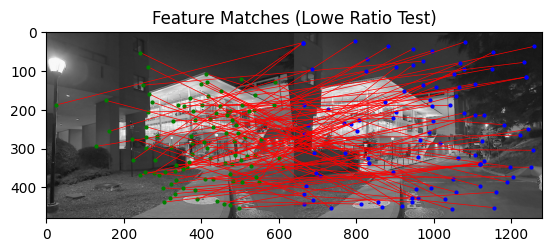

In [ ]:
matches1, matches2 = match_features(fd1, fd2, valid_coords, valid_coords) # self-matching for testing

im_combined = np.hstack((im1, im2))
plt.imshow(im_combined, cmap = 'gray')
plt.title("Feature Matches (Lowe Ratio Test)")
offset = im1.shape[1]

for (y1, x1), (y2, x2) in zip(matches1.T, matches2.T):
    plt.plot([x1, x2 + offset], [y1, y2], 'r-', linewidth = 0.5)
    plt.plot(x1, y1, 'go', markersize = 2)
    plt.plot(x2 + offset, y2, 'bo', markersize = 2)
plt.show()